<a href="https://colab.research.google.com/github/jaityagi63/ml_scratch/blob/master/pytorch/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
print(f'torch Version: {torch.__version__}')
print(f'cuda Available: {torch.cuda.is_available()}')
print(f'Cudo version: {torch.version.cuda}')

if torch.cuda.is_available():
  print(f'GPU Device: {torch.cuda.get_device_name(0)}')
else:
  print('No GPU device available.')

torch Version: 2.11.0+cpu
cuda Available: False
Cudo version: None
No GPU device available.


In [ ]:
Weight = 0.7
Bias = 0.3

X = torch.linspace(2, 9, 30).unsqueeze(dim=1)

y = Weight * X + Bias

print(f'value in X: {X[:8]}')
print('-'*100)
print(f'value in y: {y[:8]}')
print('-'*100)
print(f'Weight: {Weight}')
print('-'*100)
print(f'Bias: {Bias}')

print(X.shape, y.shape)

value in X: tensor([[2.0000],
        [2.2414],
        [2.4828],
        [2.7241],
        [2.9655],
        [3.2069],
        [3.4483],
        [3.6897]])
----------------------------------------------------------------------------------------------------
value in y: tensor([[1.7000],
        [1.8690],
        [2.0379],
        [2.2069],
        [2.3759],
        [2.5448],
        [2.7138],
        [2.8828]])
----------------------------------------------------------------------------------------------------
Weight: 0.7
----------------------------------------------------------------------------------------------------
Bias: 0.3
torch.Size([30, 1]) torch.Size([30, 1])


In [ ]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]


print(f'train_split: {train_split}')
print(f'X_train: {X_train.shape}')

train_split: 24
X_train: torch.Size([24, 1])


In [ ]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_dataLoader = DataLoader(dataset=train_dataset,
                              batch_size=8,
                              shuffle=True,
                              num_workers=0)

test_dataLoader = DataLoader(dataset=test_dataset,
                             batch_size=8,
                             shuffle=False,
                             num_workers=0)


print(len(train_dataLoader), len(test_dataLoader))

3 1


In [ ]:
for Batch_x, Batch_y in train_dataLoader:
  print(Batch_x.flatten())
  print(Batch_y.flatten())
  print(Batch_x.shape, Batch_y.shape)
  break

tensor([3.2069, 6.1034, 6.5862, 4.8966, 5.6207, 4.1724, 3.6897, 2.2414])
tensor([2.5448, 4.5724, 4.9103, 3.7276, 4.2345, 3.2207, 2.8828, 1.8690])
torch.Size([8, 1]) torch.Size([8, 1])


In [ ]:
import matplotlib.pyplot as plt
def data_visu(train_data=X_train,
              train_label=y_train,
              test_data=X_test,
              test_label=y_test,
              prediction=None):
  plt.figure(figsize=(5, 5))

  plt.scatter(train_data, train_label , c='green',s=6,alpha=0.6,label="Training data",marker='o')
  plt.scatter(test_data, test_label, c='blue',s=6,alpha=0.7,label="test_data",marker='s')
  if prediction is not None:
    plt.scatter(test_data, prediction,c="red",s=6,alpha=0.8,label="prediction",marker="^")

  plt.xlabel("input feature {x}")
  plt.ylabel("Target feature {y}")
  plt.title("Linear Regression")
  plt.legend(fontsize=12)
  plt.grid(True,alpha=0.3)
  plt.show()

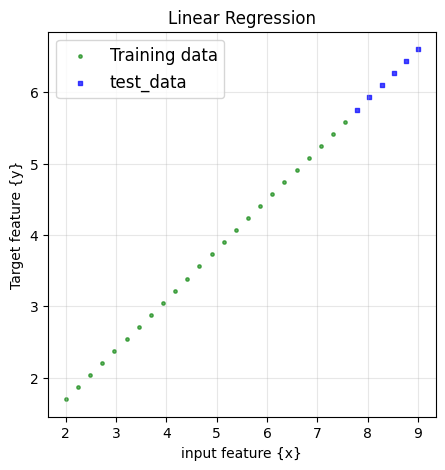

In [ ]:
data_visu()

In [ ]:
import torch.nn as nn

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.weight = nn.Parameter(torch.randn(1, dtype=torch.float),requires_grad=True)
    self.bias = nn.Parameter(torch.rand(1, dtype=torch.float),requires_grad=True)

  def forward(self, x: torch.tensor) -> torch.tensor:
    return self.weight * x + self.bias


In [ ]:
torch.manual_seed(42)

In [ ]:
model = LinearRegressionModel()
x = torch.tensor([[1],[2],[3]])

x , x.shape
y_pred = model(x)
y_pred
list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.3904], requires_grad=True)]

In [ ]:
list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.3904], requires_grad=True)]

In [ ]:
model.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.3904]))])

In [ ]:
with torch.inference_mode():
  y_pred = model(X_test)

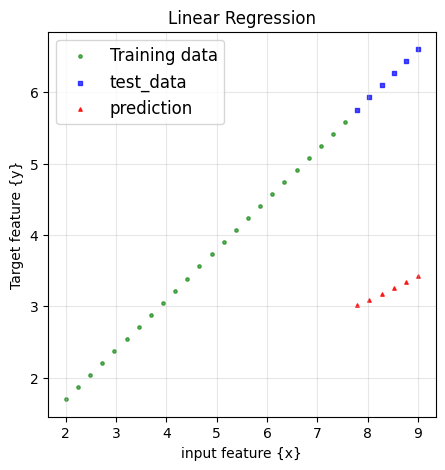

In [ ]:
data_visu(prediction=y_pred)

In [ ]:
loss_fn = nn.L1Loss()

optimiser = torch.optim.SGD(
    params=model.parameters(),
    lr=0.00008
)

print(optimiser)
print(optimiser.param_groups[0]['lr'])

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 8e-05
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
8e-05


In [ ]:
# epoxh = 100

# for epoch in range(epoxh):
#   model.train()

#   y_pred = model(X_train)

#   loss = loss_fn(y_pred, y_train)

#   optimiser.zero_grad()

#   loss.backward()

#   optimiser.step()

#   model.eval()

#   with torch.inference_mode():
#        y_pred = model(X_test)
#        test_loss = loss_fn(y_pred, y_test)

#        if epoch % 10 == 0:
#          print("="*60)
#          print(f'epoch: {epoch} | loss: {loss} | test_loss: {test_loss}')
#         #  data_visu(prediction=y_pred)

0 1.6427737871805828 2.9502360820770264


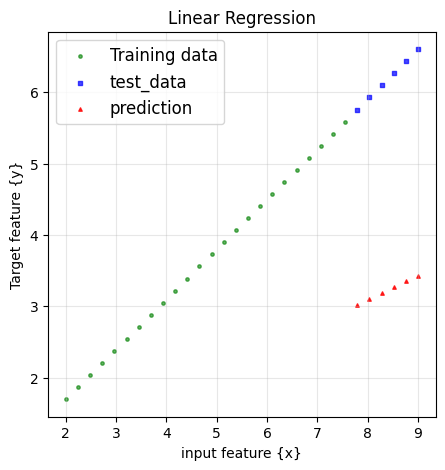

20 1.5284837484359741 2.7529544830322266


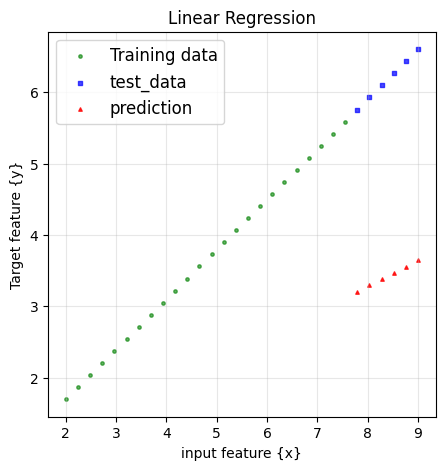

40 1.4142040014266968 2.555673122406006


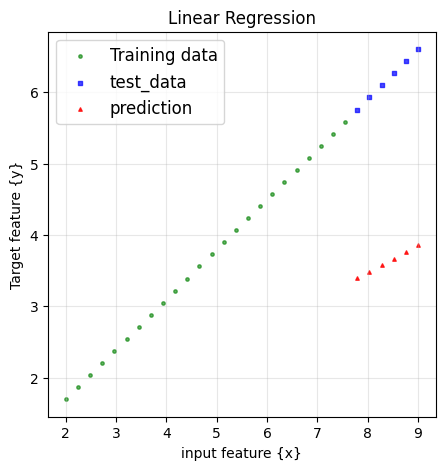

60 1.2999528646469116 2.358391523361206


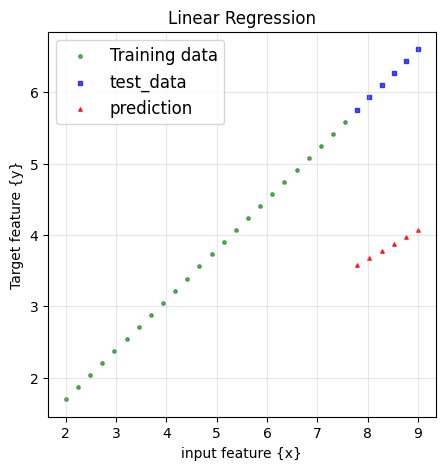

80 1.1856544812520344 2.1611101627349854


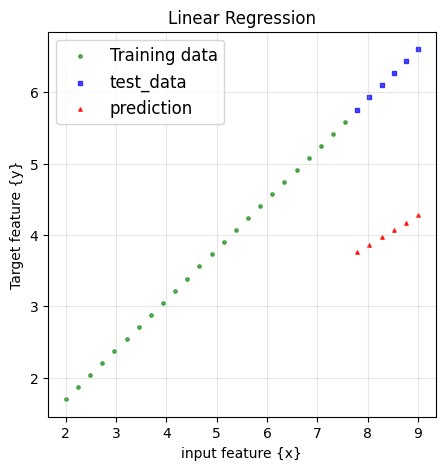

100 1.0713612635930378 1.9638285636901855


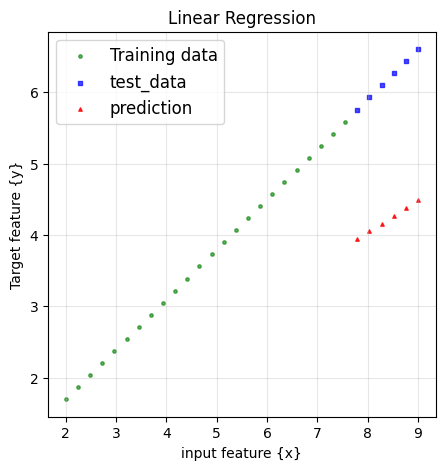

120 0.9570940534273783 1.7665472030639648


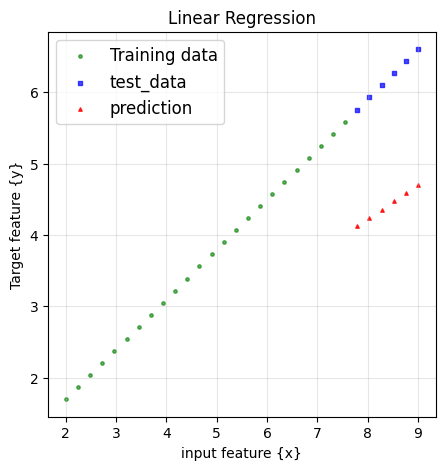

140 0.8428045908610026 1.5692654848098755


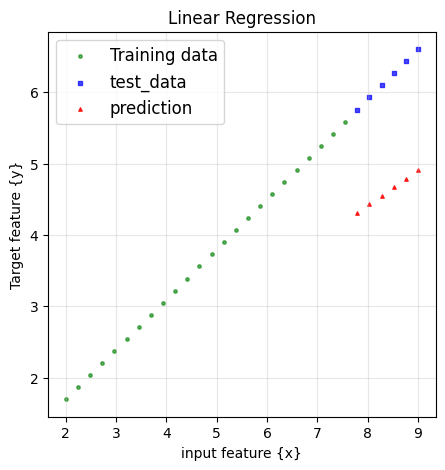

160 0.7285189628601074 1.3719806671142578


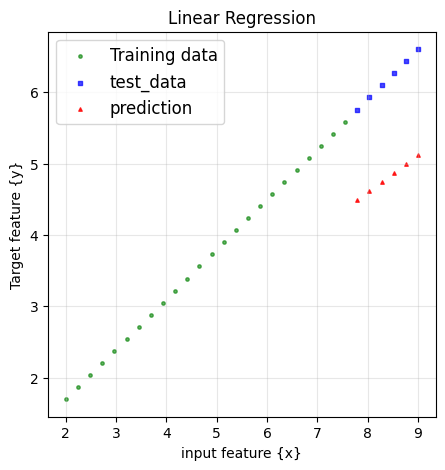

180 0.6142412821451823 1.1746931076049805


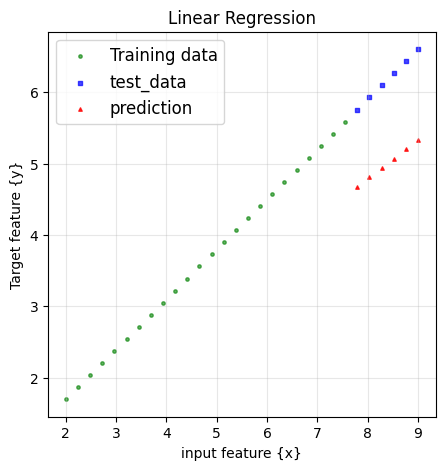

200 0.4999605019887288 0.9774066805839539


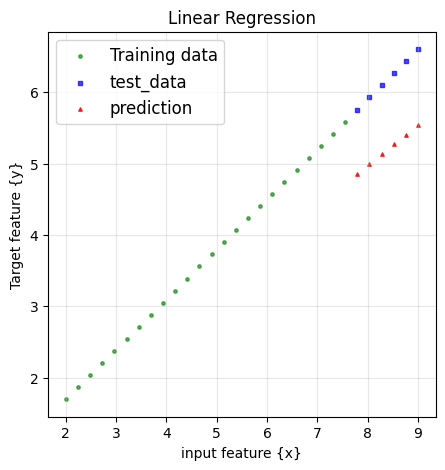

220 0.3856714367866516 0.780120849609375


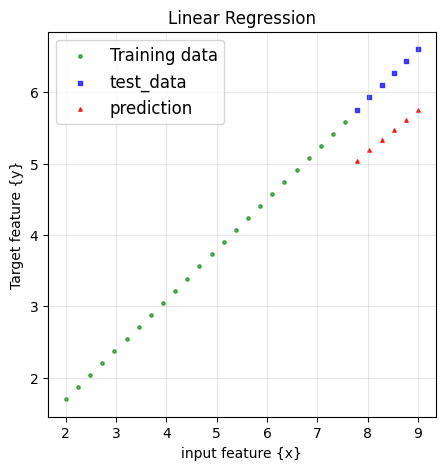

240 0.2713889926671982 0.5828344225883484


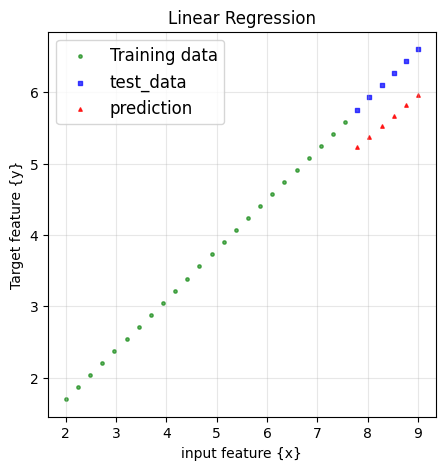

260 0.16196580231189728 0.3902965486049652


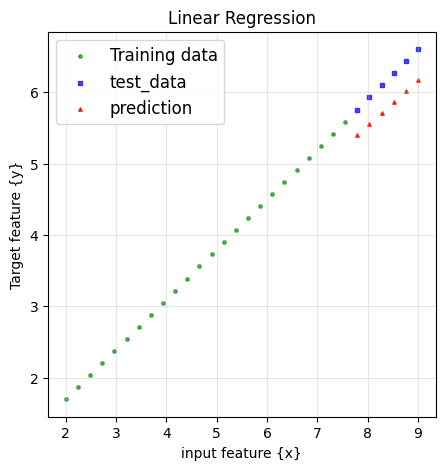

280 0.08272529145081838 0.22759675979614258


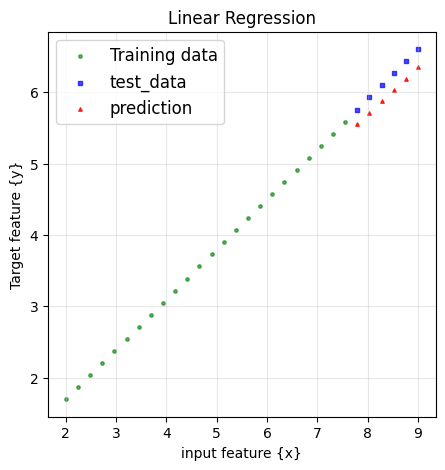

300 0.04899826645851135 0.12452856451272964


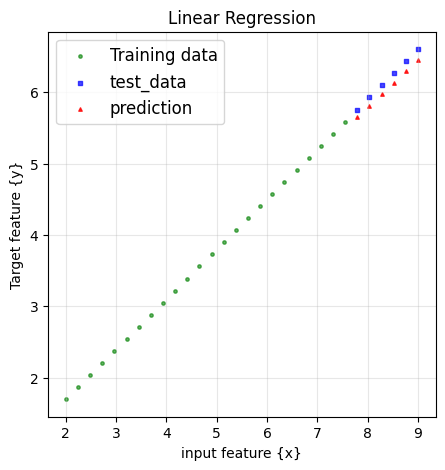

320 0.044328982631365456 0.08762399107217789


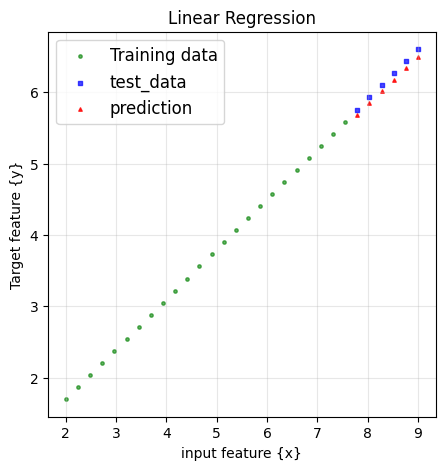

340 0.04355792701244354 0.08130248636007309


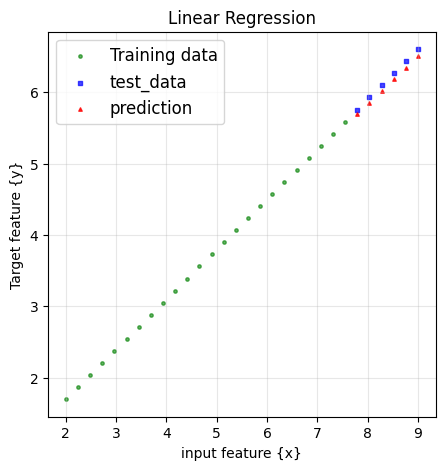

360 0.0431548406680425 0.07782991975545883


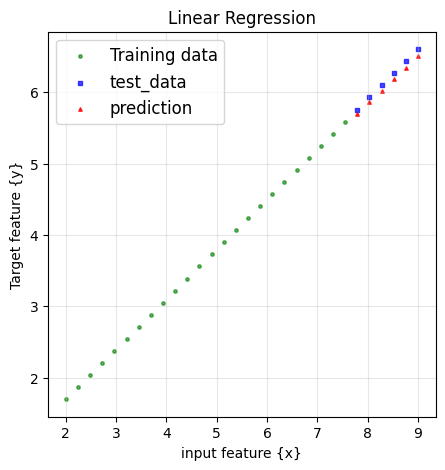

380 0.042771115899086 0.0753224715590477


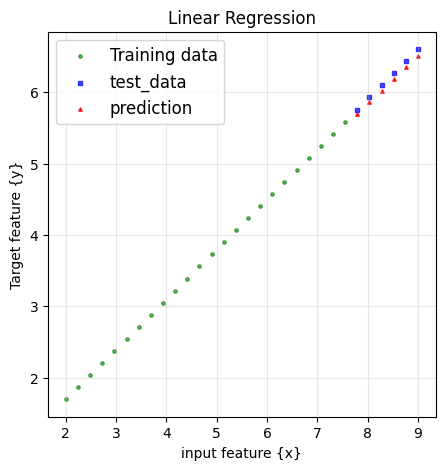

400 0.042571390668551125 0.07570815086364746


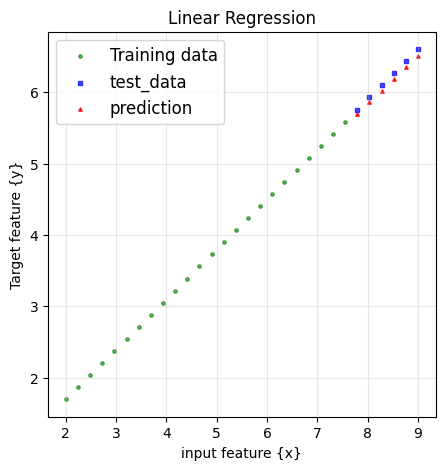

Training Complete
Final Train Loss: 0.042043099800745644
Final Test Loss: 0.07443396002054214


In [ ]:
epochs = 420
prin_inter = 20

train_loss = []
test_loss = []
epoch_count = []

for epoch in range(epochs):

    # -------------------
    # Training
    # -------------------
    model.train()

    epoch_train_loss = 0.0
    train_batch_count = 0

    for batch_X, batch_Y in train_dataLoader:

        # Prediction
        y_pred = model(batch_X)

        # Calculate loss
        loss = loss_fn(batch_Y, y_pred)

        # Reset gradients
        optimiser.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimiser.step()

        epoch_train_loss += loss.item()
        train_batch_count += 1

    avg_train_loss = epoch_train_loss / train_batch_count


    # -------------------
    # Testing
    # -------------------
    model.eval()

    epoch_test_loss = 0.0
    test_batch_count = 0

    with torch.inference_mode():

        for batch_x, batch_y in test_dataLoader:

            test_pred = model(batch_x)

            batch_test_loss = loss_fn(batch_y, test_pred)

            epoch_test_loss += batch_test_loss.item()
            test_batch_count += 1

    avg_test_loss = epoch_test_loss / test_batch_count


    # -------------------
    # Print results
    # -------------------
    if epoch % prin_inter == 0:

        epoch_count.append(epoch)
        train_loss.append(avg_train_loss)
        test_loss.append(avg_test_loss)

        print(epoch, avg_train_loss, avg_test_loss)

        with torch.inference_mode():
            test_pred = model(X_test)
        data_visu(prediction=test_pred)


print("=" * 60)
print("Training Complete")

print("Final Train Loss:", avg_train_loss)
print("Final Test Loss:", avg_test_loss)

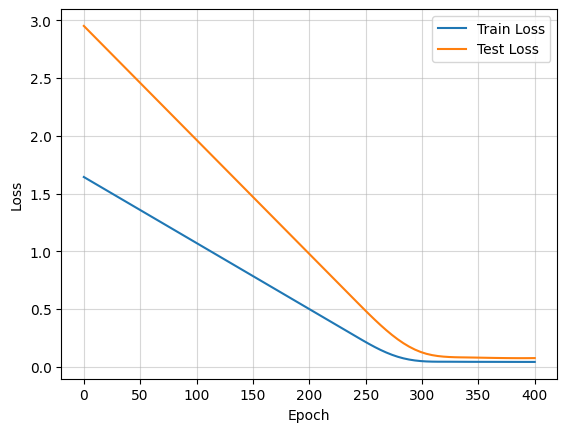

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

x_smooth = np.linspace(min(epoch_count), max(epoch_count), 80)

train_smooth = make_interp_spline(epoch_count, train_loss)(x_smooth)
test_smooth = make_interp_spline(epoch_count, test_loss)(x_smooth)

plt.plot(x_smooth, train_smooth, label="Train Loss")
plt.plot(x_smooth, test_smooth, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [ ]:
learned_param = model.state_dict()

for name, val in learned_param.items():
  print(f'{name}: {val}')

print(Weight)
print(Bias)

weight: tensor([0.6732])
bias: tensor([0.4505])
0.7
0.3


In [ ]:
from pathlib import Path

MODEL_PATH = Path('model')
MODEL_PATH.mkdir(parents=True,exist_ok=True)

print(f"path of the model is {MODEL_PATH.absolute()}")

MODEL_NAME = "01_model.pth"

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"path of the model is {MODEL_SAVE_PATH.absolute()}")


torch.save(obj=model.state_dict(),
           f=MODEL_SAVE_PATH)



path of the model is /content/model
path of the model is /content/model/01_model.pth


In [ ]:
if MODEL_SAVE_PATH.exists():
  file_info = MODEL_SAVE_PATH.stat().st_size
  print(f"file size: {file_info}")
  print(len(model.state_dict()))

file size: 1901
2


In [ ]:
models_weigth = torch.load(MODEL_SAVE_PATH,weights_only=True)

for weight_name, weight_val in models_weigth.items():
  print(f'{weight_name}: {weight_val}')

weight: tensor([0.6732])
bias: tensor([0.4505])


In [ ]:
import torch
torch.__version__

'2.11.0+cpu'